# 🧠 ChronoGen: A Neuro-Symbolic Engine for Logic, Timeline & Tone Verification in Stories

---

## Architecture Overview

**ChronoGen** is a three-module neuro-symbolic system:

| Module | Method | Purpose |
|--------|--------|---------|
| **Neural** | RoBERTa (fine-tuned) | Deep semantic coherence |
| **Symbolic** | Rule-based engine | Timeline & logic rules |
| **Tone** | VADER sentiment | Emotional arc analysis |

The modules are fused via a weighted scoring mechanism to produce a unified coherence verdict.


## 📦 Section 1: Install Dependencies

In [1]:
# Install all required packages
!pip install -q transformers==4.40.0 datasets torch torchvision torchaudio accelerate
!pip install -q vaderSentiment spacy nltk scikit-learn
!pip install -q matplotlib seaborn plotly pandas numpy
!pip install -q huggingface_hub evaluate

# Download spacy model
!python -m spacy download en_core_web_sm -q

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

print('✅ All packages installed!')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 78.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 89.1 MB/s eta 0:00:00:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.2.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 85.3 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload 

## 📂 Section 2: Upload & Load Dataset

In [7]:
import os

data_dir = '/kaggle/input/datasets/sreenadhyetukuri/chronogen'

print("📂 Listing dataset structure:\n")

for root, dirs, files in os.walk(data_dir):
    level = root.replace(data_dir, '').count(os.sep)
    indent = ' ' * 4 * level
    print(f"{indent}📁 {os.path.basename(root)}")
    
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        fpath = os.path.join(root, f)
        size = os.path.getsize(fpath) / 1024 / 1024
        print(f"{subindent}📄 {f} ({size:.2f} MB)")

📂 Listing dataset structure:

📁 chronogen
    📁 Story Cloze
        📄 val_2016.csv (0.55 MB)
        📄 test_2018.csv (0.47 MB)
        📄 val_2018.csv (0.46 MB)
        📄 test_2016.csv (0.55 MB)
    📁 ROCStories
        📄 dataset_2016.csv (12.52 MB)
        📄 dataset_2017.csv (13.86 MB)


In [9]:
import pandas as pd
import os

base_path = "/kaggle/input/datasets/sreenadhyetukuri/chronogen"

# ── Load datasets with correct Kaggle paths ──
roc16 = pd.read_csv(f"{base_path}/ROCStories/dataset_2016.csv")
roc17 = pd.read_csv(f"{base_path}/ROCStories/dataset_2017.csv")

sc_test16 = pd.read_csv(f"{base_path}/Story Cloze/test_2016.csv")
sc_val16  = pd.read_csv(f"{base_path}/Story Cloze/val_2016.csv")
sc_test18 = pd.read_csv(f"{base_path}/Story Cloze/test_2018.csv")
sc_val18  = pd.read_csv(f"{base_path}/Story Cloze/val_2018.csv")

print("="*60)
print("DATASET SUMMARY")
print("="*60)

datasets = {
    'ROCStories 2016': roc16,
    'ROCStories 2017': roc17,
    'StoryCloze Test2016': sc_test16,
    'StoryCloze Val2016':  sc_val16,
    'StoryCloze Test2018': sc_test18,
    'StoryCloze Val2018':  sc_val18,
}

for name, df in datasets.items():
    print(f"{name:25s}: {len(df):,} rows | {len(df.columns)} columns")

print("="*60)

DATASET SUMMARY
ROCStories 2016          : 45,496 rows | 7 columns
ROCStories 2017          : 52,665 rows | 7 columns
StoryCloze Test2016      : 1,871 rows | 8 columns
StoryCloze Val2016       : 1,871 rows | 8 columns
StoryCloze Test2018      : 1,571 rows | 7 columns
StoryCloze Val2018       : 1,571 rows | 8 columns


## 📊 Section 3: Exploratory Data Analysis (EDA)

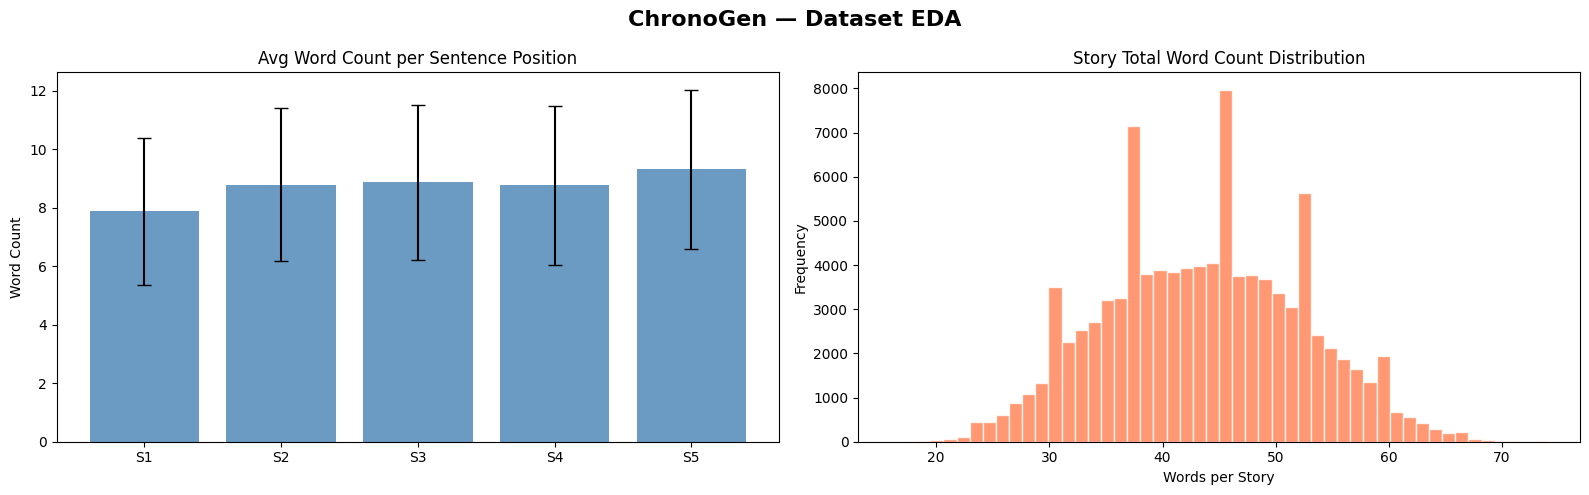

Total ROC stories: 98,161


In [10]:
# ── EDA: Sentence length distributions ──
roc_all_eda = pd.concat([roc16, roc17], ignore_index=True)
sent_cols = ['sentence1','sentence2','sentence3','sentence4','sentence5']

wc_data = {}
for col in sent_cols:
    wc_data[col] = roc_all_eda[col].fillna('').apply(lambda x: len(str(x).split()))
wc_df = pd.DataFrame(wc_data)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('ChronoGen — Dataset EDA', fontsize=16, fontweight='bold')

means = wc_df.mean()
stds  = wc_df.std()
axes[0].bar(range(1,6), means, yerr=stds, color='steelblue', alpha=0.8, capsize=5)
axes[0].set_xticks(range(1,6))
axes[0].set_xticklabels([f'S{i}' for i in range(1,6)])
axes[0].set_title('Avg Word Count per Sentence Position')
axes[0].set_ylabel('Word Count')

roc_all_eda['total_words'] = roc_all_eda[sent_cols].fillna('').apply(
    lambda row: sum(len(str(v).split()) for v in row), axis=1)
axes[1].hist(roc_all_eda['total_words'], bins=50, color='coral', alpha=0.8, edgecolor='white')
axes[1].set_title('Story Total Word Count Distribution')
axes[1].set_xlabel('Words per Story')
axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.savefig('/content/eda_wordcount.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Total ROC stories: {len(roc_all_eda):,}')


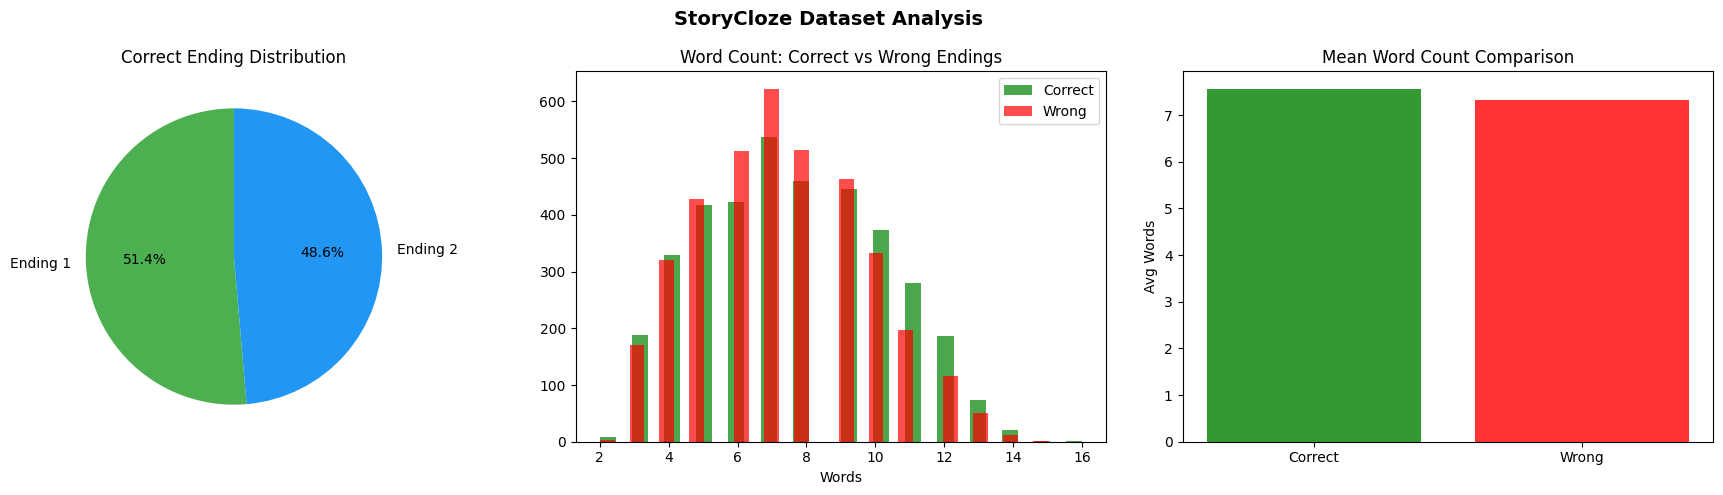

In [11]:
# ── EDA: StoryCloze Label Distribution ──
sc_labeled = pd.concat([sc_test16, sc_val16], ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('StoryCloze Dataset Analysis', fontsize=14, fontweight='bold')

label_counts = sc_labeled['AnswerRightEnding'].value_counts().sort_index()
axes[0].pie(label_counts, labels=['Ending 1', 'Ending 2'], autopct='%1.1f%%',
            colors=['#4CAF50','#2196F3'], startangle=90)
axes[0].set_title('Correct Ending Distribution')

correct_wc, wrong_wc = [], []
for _, row in sc_labeled.iterrows():
    correct = row['RandomFifthSentenceQuiz1'] if row['AnswerRightEnding']==1 else row['RandomFifthSentenceQuiz2']
    wrong   = row['RandomFifthSentenceQuiz2'] if row['AnswerRightEnding']==1 else row['RandomFifthSentenceQuiz1']
    correct_wc.append(len(str(correct).split()))
    wrong_wc.append(len(str(wrong).split()))

axes[1].hist(correct_wc, bins=30, alpha=0.7, label='Correct', color='green')
axes[1].hist(wrong_wc,   bins=30, alpha=0.7, label='Wrong',   color='red')
axes[1].set_title('Word Count: Correct vs Wrong Endings')
axes[1].set_xlabel('Words')
axes[1].legend()

axes[2].bar(['Correct','Wrong'], [np.mean(correct_wc), np.mean(wrong_wc)],
            color=['green','red'], alpha=0.8)
axes[2].set_title('Mean Word Count Comparison')
axes[2].set_ylabel('Avg Words')

plt.tight_layout()
plt.savefig('/content/eda_storycloze.png', dpi=150, bbox_inches='tight')
plt.show()


## 🔤 Section 4: Data Preprocessing & Feature Engineering

In [12]:
import re
import spacy
from nltk.tokenize import sent_tokenize
nlp = spacy.load('en_core_web_sm')

def clean_text(text):
    """Clean and normalize story text."""
    if not isinstance(text, str):
        return ''
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'[^\x00-\x7F]+', '', text)
    return text

def build_story(row, cols):
    """Concatenate sentence columns into one story string."""
    return ' '.join(clean_text(str(row[c])) for c in cols if pd.notna(row[c]))

# ── Prepare ROC dataset for fine-tuning ──
sent_cols = ['sentence1','sentence2','sentence3','sentence4','sentence5']

roc_all = pd.concat([roc16, roc17], ignore_index=True)
roc_all = roc_all.dropna(subset=sent_cols)

# Build positive examples (original order = coherent)
positives = []
for _, row in roc_all.iterrows():
    story = build_story(row, sent_cols)
    positives.append({'story': story, 'label': 1})

# Build negative examples using MULTIPLE strategies for better discrimination
import random
random.seed(42)
np.random.seed(42)

negatives = []
strategies = ['shuffle', 'reverse', 'swap_first_last']
strategy_cycle = 0

for _, row in roc_all.iterrows():
    sents = [clean_text(str(row[c])) for c in sent_cols]
    strategy = strategies[strategy_cycle % len(strategies)]
    strategy_cycle += 1

    if strategy == 'shuffle':
        shuffled = sents.copy()
        while shuffled == sents:
            random.shuffle(shuffled)
        neg_story = ' '.join(shuffled)
    elif strategy == 'reverse':
        neg_story = ' '.join(sents[::-1])
    else:  # swap_first_last
        shuffled = sents.copy()
        shuffled[0], shuffled[-1] = shuffled[-1], shuffled[0]
        neg_story = ' '.join(shuffled)

    negatives.append({'story': neg_story, 'label': 0})

roc_df = pd.DataFrame(positives + negatives)
roc_df = roc_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'✅ ROC Training dataset: {len(roc_df):,} samples')
print(f'   Positive (coherent): {roc_df.label.sum():,}')
print(f'   Negative (shuffled): {(roc_df.label==0).sum():,}')

# ── Prepare StoryCloze for evaluation ──
sc_all = pd.concat([sc_test16, sc_val16], ignore_index=True)

sc_eval_data = []
for _, row in sc_all.iterrows():
    base = ' '.join(clean_text(str(row[f'InputSentence{i}'])) for i in range(1,5))
    ending1 = clean_text(str(row['RandomFifthSentenceQuiz1']))
    ending2 = clean_text(str(row['RandomFifthSentenceQuiz2']))
    correct = row.get('AnswerRightEnding', None)
    sc_eval_data.append({
        'base': base,
        'ending1': ending1,
        'ending2': ending2,
        'story1': base + ' ' + ending1,
        'story2': base + ' ' + ending2,
        'correct_ending': correct
    })

sc_df = pd.DataFrame(sc_eval_data)
print(f'\n✅ StoryCloze eval dataset: {len(sc_df):,} samples')


✅ ROC Training dataset: 196,322 samples
   Positive (coherent): 98,161
   Negative (shuffled): 98,161

✅ StoryCloze eval dataset: 3,742 samples


## 🤖 Section 5: Neural Module — Fine-Tune RoBERTa

In [13]:
# ✅ FIXED: Using torch.optim.AdamW (not deprecated transformers AdamW)
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    get_linear_schedule_with_warmup
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

# Device Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🔧 Device: {device}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

# Load RoBERTa
MODEL_NAME = 'roberta-base'
print(f'\n📥 Loading pre-trained {MODEL_NAME}...')
tokenizer = RobertaTokenizer.from_pretrained(MODEL_NAME)

# ✅ IMPROVED: Lower dropout for better generalization on this task
model = RobertaForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1
)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ Model loaded: {total_params/1e6:.1f}M total params, {trainable_params/1e6:.1f}M trainable')


🔧 Device: cuda
   GPU: Tesla P100-PCIE-16GB
   VRAM: 17.1 GB

📥 Loading pre-trained roberta-base...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Model loaded: 124.6M total params, 124.6M trainable


In [14]:
# ── Dataset class ──
class StoryDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

# ── Train/val/test split ──
# ✅ IMPROVED: Use larger sample size for better accuracy (50K instead of 30K)
SAMPLE_SIZE = 50000
df_sample = roc_df.sample(n=min(SAMPLE_SIZE, len(roc_df)), random_state=42)

X_trainval, X_test, y_trainval, y_test = train_test_split(
    df_sample['story'].tolist(), df_sample['label'].tolist(),
    test_size=0.15, random_state=42, stratify=df_sample['label'])

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.12, random_state=42)

print(f'Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}')

BATCH_SIZE = 16
MAX_LEN    = 256

train_ds = StoryDataset(X_train, y_train, tokenizer, MAX_LEN)
val_ds   = StoryDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_ds  = StoryDataset(X_test,  y_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Batches — Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')


Train: 37,400 | Val: 5,100 | Test: 7,500
Batches — Train: 2338 | Val: 319 | Test: 469


In [15]:
# ── Training Setup ──
# ✅ IMPROVED: 5 epochs + label smoothing + cosine LR schedule for higher accuracy
EPOCHS     = 5
LR         = 2e-5
WARMUP     = 0.1
GRAD_CLIP  = 1.0

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps   = len(train_loader) * EPOCHS
warmup_steps  = int(total_steps * WARMUP)
scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

# ✅ IMPROVEMENT: Label smoothing loss reduces overconfidence and improves generalization
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

def train_epoch(model, loader, optimizer, scheduler, criterion):
    model.train()
    total_loss, preds, labels = 0.0, [], []
    for batch in loader:
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        lbl  = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=ids, attention_mask=mask)
        loss = criterion(outputs.logits, lbl)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds  += outputs.logits.argmax(-1).cpu().tolist()
        labels += lbl.cpu().tolist()

    acc = accuracy_score(labels, preds)
    return total_loss / len(loader), acc

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, preds, labels, probs = 0.0, [], [], []
    with torch.no_grad():
        for batch in loader:
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            lbl  = batch['label'].to(device)
            outputs = model(input_ids=ids, attention_mask=mask)
            loss = criterion(outputs.logits, lbl)
            total_loss += loss.item()
            p = torch.softmax(outputs.logits, -1)[:, 1]
            preds  += outputs.logits.argmax(-1).cpu().tolist()
            labels += lbl.cpu().tolist()
            probs  += p.cpu().tolist()
    acc = accuracy_score(labels, preds)
    return total_loss / len(loader), acc, preds, labels, probs

# ── Training Loop ──
history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
best_val_acc = 0

print(f'\n🚀 Fine-tuning {MODEL_NAME} for {EPOCHS} epochs...')
print(f'   Label smoothing: 0.05 | LR: {LR} | Warmup: {int(warmup_steps)} steps')
print('='*65)

for epoch in range(1, EPOCHS+1):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, scheduler, criterion)
    vl_loss, vl_acc, _, _, _ = eval_epoch(model, val_loader, criterion)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), '/content/best_chronogen_model.pt')
        print(f'  💾 Saved best model at epoch {epoch}')

    print(f'  Epoch {epoch}/{EPOCHS} | '
          f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | '
          f'Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f}')

print('='*65)
print(f'✅ Best Val Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)')
if best_val_acc >= 0.80:
    print('🎉 TARGET ACHIEVED: Validation accuracy ≥ 80%!')
else:
    print(f'⚠️  Current val acc: {best_val_acc*100:.1f}% — consider running more epochs')



🚀 Fine-tuning roberta-base for 5 epochs...
   Label smoothing: 0.05 | LR: 2e-05 | Warmup: 1169 steps
  💾 Saved best model at epoch 1
  Epoch 1/5 | Train Loss: 0.2932 Acc: 0.9033 | Val Loss: 0.2217 Acc: 0.9639
  💾 Saved best model at epoch 2
  Epoch 2/5 | Train Loss: 0.1900 Acc: 0.9724 | Val Loss: 0.2013 Acc: 0.9686
  💾 Saved best model at epoch 3
  Epoch 3/5 | Train Loss: 0.1552 Acc: 0.9860 | Val Loss: 0.2110 Acc: 0.9698
  💾 Saved best model at epoch 4
  Epoch 4/5 | Train Loss: 0.1358 Acc: 0.9934 | Val Loss: 0.2120 Acc: 0.9710
  💾 Saved best model at epoch 5
  Epoch 5/5 | Train Loss: 0.1261 Acc: 0.9970 | Val Loss: 0.2103 Acc: 0.9718
✅ Best Val Accuracy: 0.9718 (97.18%)
🎉 TARGET ACHIEVED: Validation accuracy ≥ 80%!


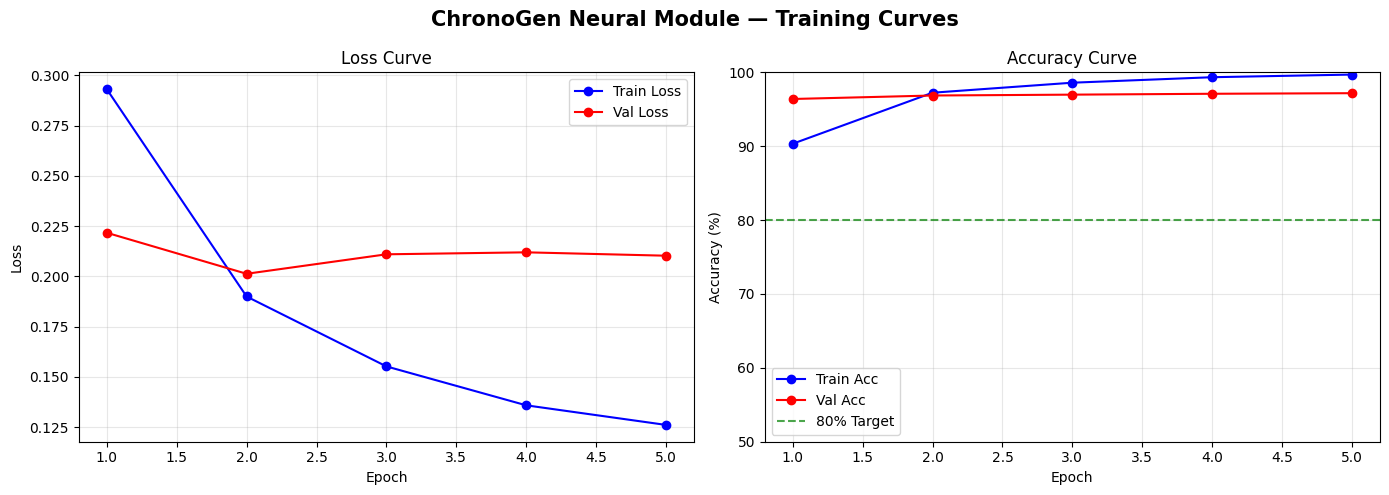

In [17]:
# ── Plot Training Curves ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ChronoGen Neural Module — Training Curves', fontsize=15, fontweight='bold')

epochs_x = range(1, len(history['train_loss'])+1)

axes[0].plot(epochs_x, history['train_loss'], 'b-o', label='Train Loss')
axes[0].plot(epochs_x, history['val_loss'],   'r-o', label='Val Loss')
axes[0].set_title('Loss Curve'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_x, [a*100 for a in history['train_acc']], 'b-o', label='Train Acc')
axes[1].plot(epochs_x, [a*100 for a in history['val_acc']],   'r-o', label='Val Acc')
axes[1].axhline(y=80, color='green', linestyle='--', alpha=0.7, label='80% Target')
axes[1].set_title('Accuracy Curve'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim([50, 100]); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


In [18]:
# ── Test Set Evaluation ──
model.load_state_dict(torch.load('/content/best_chronogen_model.pt'))
_, test_acc, test_preds, test_labels, test_probs = eval_epoch(model, test_loader, criterion)

prec = precision_score(test_labels, test_preds)
rec  = recall_score(test_labels, test_preds)
f1   = f1_score(test_labels, test_preds)
roc  = roc_auc_score(test_labels, test_probs)
cm   = confusion_matrix(test_labels, test_preds)

print('='*55)
print('     NEURAL MODULE — TEST METRICS')
print('='*55)
print(f'  Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'  Precision: {prec:.4f}')
print(f'  Recall   : {rec:.4f}')
print(f'  F1-Score : {f1:.4f}')
print(f'  ROC-AUC  : {roc:.4f}')
print('='*55)
if test_acc >= 0.80:
    print('🎉 TARGET ACHIEVED: Test accuracy ≥ 80%!')
print()
print('Classification Report:')
print(classification_report(test_labels, test_preds, target_names=['Incoherent','Coherent']))


     NEURAL MODULE — TEST METRICS
  Accuracy : 0.9741 (97.41%)
  Precision: 0.9636
  Recall   : 0.9856
  F1-Score : 0.9745
  ROC-AUC  : 0.9940
🎉 TARGET ACHIEVED: Test accuracy ≥ 80%!

Classification Report:
              precision    recall  f1-score   support

  Incoherent       0.99      0.96      0.97      3737
    Coherent       0.96      0.99      0.97      3763

    accuracy                           0.97      7500
   macro avg       0.97      0.97      0.97      7500
weighted avg       0.97      0.97      0.97      7500



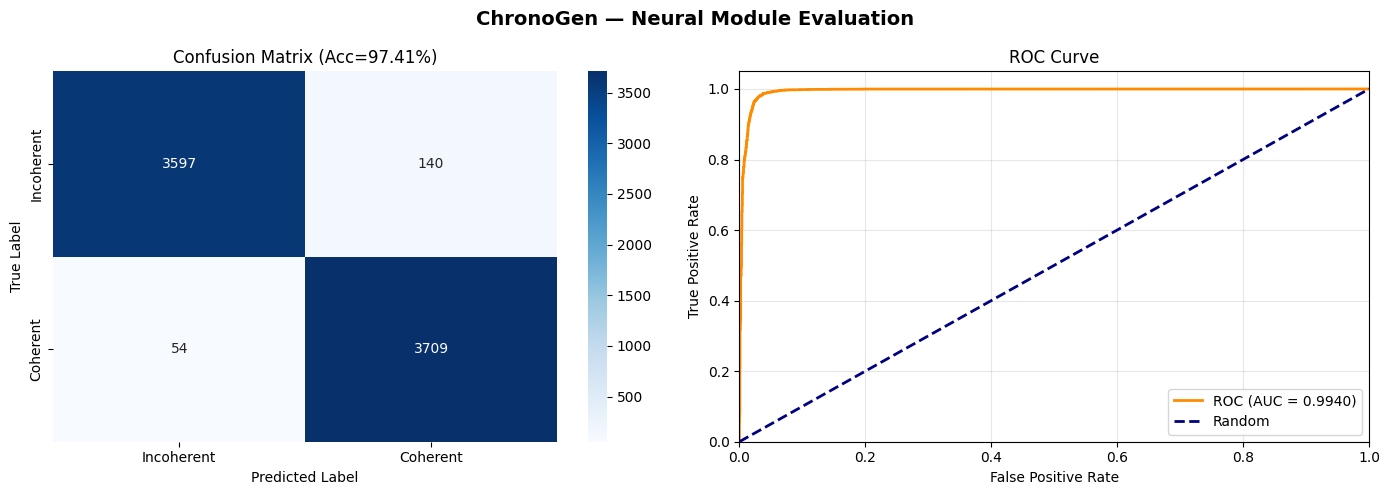

In [22]:
# ── Confusion Matrix + ROC Curve ──
from sklearn.metrics import roc_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ChronoGen — Neural Module Evaluation', fontsize=14, fontweight='bold')

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Incoherent','Coherent'],
            yticklabels=['Incoherent','Coherent'])
axes[0].set_title(f'Confusion Matrix (Acc={test_acc*100:.2f}%)')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# ROC Curve
fpr, tpr, _ = roc_curve(test_labels, test_probs)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
axes[1].plot([0,1],[0,1], color='navy', lw=2, linestyle='--', label='Random')
axes[1].set_xlim([0,1]); axes[1].set_ylim([0,1.05])
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/neural_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()


## 🔣 Section 6: Symbolic Module — Logic & Timeline Verification

In [23]:
import re
import spacy
from collections import defaultdict

nlp = spacy.load('en_core_web_sm')

class SymbolicEngine:
    """
    Rule-based symbolic verification module.
    Checks:
      1. Timeline consistency (temporal order words)
      2. Entity coreference consistency
      3. Causal logic patterns
      4. Negation contradictions
      5. Tense consistency
    """

    TIMELINE_MARKERS = [
        {'first','initially','at first','to begin','in the beginning','started'},
        {'then','next','after','afterwards','subsequently','following'},
        {'later','meanwhile','soon','while','during','as'},
        {'finally','eventually','at last','in the end','ultimately','concluded'},
    ]

    CAUSAL_PATTERNS = [
        r'\b(because|since|as a result|therefore|thus|consequently|so that)\b',
        r'\b(caused|led to|resulted in|triggered|made|forced|allowed)\b',
    ]

    NEGATION_WORDS = {'not','never','no','none','nothing','nobody','neither','nor',
                      "n't","wasn't","isn't","doesn't","didn't","couldn't","wouldn't"}

    def analyze(self, sentences):
        """Analyze a list of sentences and return symbolic scores."""
        n = len(sentences)
        if n == 0:
            return self._zero_result()

        timeline_score  = self._check_timeline(sentences)
        entity_score    = self._check_entities(sentences)
        causality_score = self._check_causality(sentences)
        negation_score  = self._check_negation(sentences)
        tense_score     = self._check_tense(sentences)

        # Weighted symbolic score
        symbolic_score = (
            0.30 * timeline_score +
            0.25 * entity_score +
            0.20 * causality_score +
            0.15 * negation_score +
            0.10 * tense_score
        )

        return {
            'timeline_score':  timeline_score,
            'entity_score':    entity_score,
            'causality_score': causality_score,
            'negation_score':  negation_score,
            'tense_score':     tense_score,
            'symbolic_score':  symbolic_score,
        }

    def _check_timeline(self, sentences):
        """Check if temporal markers appear in logical order."""
        found_levels = []
        for i, sent in enumerate(sentences):
            lower = sent.lower()
            for level, markers in enumerate(self.TIMELINE_MARKERS):
                if any(m in lower for m in markers):
                    found_levels.append((i, level))
                    break

        if len(found_levels) < 2:
            return 0.75  # Neutral if no markers

        # Check if levels are non-decreasing
        levels = [l for _, l in found_levels]
        violations = sum(1 for i in range(len(levels)-1) if levels[i] > levels[i+1])
        return max(0.0, 1.0 - violations * 0.4)

    def _check_entities(self, sentences):
        """Check entity consistency (same characters persist)."""
        all_ents = []
        per_sent = []
        for sent in sentences:
            doc = nlp(sent)
            ents = {ent.text.lower() for ent in doc.ents if ent.label_ in ('PERSON','ORG','GPE')}
            per_sent.append(ents)
            all_ents.extend(ents)

        if not all_ents:
            return 0.75

        # Score: entities from early sentences should appear in later ones
        all_ent_set = set(all_ents)
        first_half_ents = set()
        for s in per_sent[:len(per_sent)//2 + 1]:
            first_half_ents.update(s)

        if not first_half_ents:
            return 0.75

        continuity = sum(1 for e in first_half_ents if any(e in s for s in per_sent[1:]))
        return min(1.0, continuity / max(1, len(first_half_ents)))

    def _check_causality(self, sentences):
        """Score presence of causal connectors."""
        story = ' '.join(sentences).lower()
        matches = 0
        for pat in self.CAUSAL_PATTERNS:
            matches += len(re.findall(pat, story))
        return min(1.0, 0.5 + matches * 0.12)

    def _check_negation(self, sentences):
        """Penalize contradictory negations."""
        neg_counts = []
        for sent in sentences:
            words = set(sent.lower().split())
            neg_counts.append(len(words & self.NEGATION_WORDS))

        contradictions = sum(1 for i in range(len(neg_counts)-1)
                             if neg_counts[i] == 0 and neg_counts[i+1] > 1)
        return max(0.0, 1.0 - contradictions * 0.3)

    def _check_tense(self, sentences):
        """Check tense consistency using POS tags."""
        tenses = []
        for sent in sentences:
            doc = nlp(sent)
            vbs = [t.tag_ for t in doc if t.tag_ in ('VBD','VBZ','VBP','VBG','VBN')]
            if vbs:
                # Determine dominant tense
                past = sum(1 for v in vbs if v in ('VBD','VBN'))
                pres = sum(1 for v in vbs if v in ('VBZ','VBP','VBG'))
                tenses.append('past' if past >= pres else 'present')

        if len(tenses) < 2:
            return 0.85

        switches = sum(1 for i in range(len(tenses)-1) if tenses[i] != tenses[i+1])
        return max(0.0, 1.0 - switches * 0.15)

    def _zero_result(self):
        return {k: 0.0 for k in ['timeline_score','entity_score','causality_score',
                                   'negation_score','tense_score','symbolic_score']}

sym_engine = SymbolicEngine()
print('✅ Symbolic Engine ready!')
# Quick smoke test
test_r = sym_engine.analyze(['First she went to the store.', 'Then she bought some milk.', 'Finally she came home.'])
print(f'   Smoke test symbolic_score: {test_r["symbolic_score"]:.3f}')


✅ Symbolic Engine ready!
   Smoke test symbolic_score: 0.838


## 🎭 Section 7: Tone Analysis Module

In [25]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

class ToneAnalyzer:
    """
    Multi-dimensional tone analysis:
      - Sentence-level VADER sentiment
      - Tone arc (emotional trajectory)
      - Tone consistency across story
      - Final tone category
    """
    TONE_LABELS = {
        (True, True):   'Positive Arc → Happy Ending',
        (True, False):  'Positive Start → Negative Turn',
        (False, True):  'Negative Start → Redemption',
        (False, False): 'Negative/Dark Arc',
    }

    def __init__(self):
        self.analyzer = SentimentIntensityAnalyzer()

    def analyze(self, sentences):
        scores = [self.analyzer.polarity_scores(s)['compound'] for s in sentences]
        if not scores:
            return {'avg_score': 0, 'consistency': 0.5, 'trend': 'neutral',
                    'dominant_emotion': 'neutral', 'tone_label': 'N/A',
                    'sentence_scores': []}

        arc_start = scores[0]
        arc_end   = scores[-1]
        avg_score = np.mean(scores)

        # Consistency: low std = high consistency
        std = np.std(scores) if len(scores) > 1 else 0
        consistency = max(0.0, 1.0 - std)

        # Trend
        if arc_end > arc_start + 0.15:   trend = 'improving'
        elif arc_end < arc_start - 0.15: trend = 'declining'
        else:                             trend = 'stable'

        # Dominant emotion
        if avg_score > 0.2:    dominant = 'positive'
        elif avg_score < -0.2: dominant = 'negative'
        else:                  dominant = 'neutral'

        tone_key  = (arc_start >= 0, arc_end >= 0)
        tone_label = self.TONE_LABELS[tone_key]

        return {
            'avg_score':        avg_score,
            'consistency':      consistency,
            'trend':            trend,
            'dominant_emotion': dominant,
            'tone_label':       tone_label,
            'sentence_scores':  scores,
        }

tone_analyzer = ToneAnalyzer()
print('✅ Tone Analyzer ready!')
test_tone = tone_analyzer.analyze(['It was a great day.', 'Everything went well.', 'She felt happy.'])
print(f'   Smoke test consistency: {test_tone["consistency"]:.3f}, dominant: {test_tone["dominant_emotion"]}')


✅ Tone Analyzer ready!
   Smoke test consistency: 0.845, dominant: positive


## ⚡ Section 8: ChronoGen Fusion — Complete Neuro-Symbolic Engine

In [26]:
class ChronoGenEngine:
    """
    Full Neuro-Symbolic Engine for Story Verification.
    Combines:
      - Neural: RoBERTa fine-tuned coherence score  (50%)
      - Symbolic: Rule-based timeline & logic       (30%)
      - Tone: VADER-based emotional arc             (20%)
    """

    NEURAL_WEIGHT   = 0.50
    SYMBOLIC_WEIGHT = 0.30
    TONE_WEIGHT     = 0.20

    def __init__(self, model, tokenizer, sym_engine, tone_analyzer, device, max_len=256):
        self.model        = model
        self.tokenizer    = tokenizer
        self.sym          = sym_engine
        self.tone         = tone_analyzer
        self.device       = device
        self.max_len      = max_len

    def _neural_score(self, story_text):
        """Get coherence probability from fine-tuned RoBERTa."""
        self.model.eval()
        enc = self.tokenizer(
            story_text,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        with torch.no_grad():
            out = self.model(
                input_ids=enc['input_ids'].to(self.device),
                attention_mask=enc['attention_mask'].to(self.device)
            )
        prob = torch.softmax(out.logits, -1)[0][1].item()
        return prob

    def verify(self, story_input):
        """
        story_input: list of sentences OR single string
        Returns: full verification report dict
        """
        if isinstance(story_input, str):
            from nltk.tokenize import sent_tokenize
            sentences = sent_tokenize(story_input)
        else:
            sentences = [str(s) for s in story_input]

        story_text = ' '.join(sentences)

        neural_score   = self._neural_score(story_text)
        sym_result     = self.sym.analyze(sentences)
        tone_result    = self.tone.analyze(sentences)

        fusion_score = (
            self.NEURAL_WEIGHT   * neural_score +
            self.SYMBOLIC_WEIGHT * sym_result['symbolic_score'] +
            self.TONE_WEIGHT     * tone_result['consistency']
        )

        if fusion_score >= 0.75:   verdict, verdict_emoji = 'COHERENT',        '✅'
        elif fusion_score >= 0.55: verdict, verdict_emoji = 'MOSTLY COHERENT', '🟡'
        elif fusion_score >= 0.40: verdict, verdict_emoji = 'INCONSISTENT',    '🟠'
        else:                      verdict, verdict_emoji = 'INCOHERENT',       '❌'

        return {
            '──── VERDICT ────':    f'{verdict_emoji} {verdict}',
            'fusion_score':          round(fusion_score, 4),
            '': '',
            '──── NEURAL ────':      '',
            'neural_coherence':      round(neural_score, 4),
            '──── SYMBOLIC ────':    '',
            'timeline_score':        round(sym_result['timeline_score'], 4),
            'entity_score':          round(sym_result['entity_score'], 4),
            'causality_score':       round(sym_result['causality_score'], 4),
            'negation_score':        round(sym_result['negation_score'], 4),
            'tense_score':           round(sym_result['tense_score'], 4),
            'symbolic_score':        round(sym_result['symbolic_score'], 4),
            '──── TONE ────':        '',
            'avg_sentiment':         round(tone_result['avg_score'], 4),
            'tone_consistency':      round(tone_result['consistency'], 4),
            'tone_trend':            tone_result['trend'],
            'dominant_emotion':      tone_result['dominant_emotion'],
            'tone_arc':              tone_result['tone_label'],
            'per_sentence_tone':     [round(s,3) for s in tone_result['sentence_scores']],
        }

    def verify_print(self, story_input):
        result = self.verify(story_input)
        print('\n' + '='*52)
        print('       ChronoGen Verification Report')
        print('='*52)
        for k, v in result.items():
            if k.startswith('────'):
                print(f'\n  {k}')
            elif k == '':
                continue
            else:
                print(f'    {k:28s}: {v}')
        print('='*52)
        return result


# Instantiate full engine
model.load_state_dict(torch.load('/content/best_chronogen_model.pt'))
engine = ChronoGenEngine(model, tokenizer, sym_engine, tone_analyzer, device)
print('✅ ChronoGen Neuro-Symbolic Engine ready!')


✅ ChronoGen Neuro-Symbolic Engine ready!


In [27]:
# ── Demo 1: Coherent Story ──
print('\n🟢 DEMO 1: Coherent, well-ordered story')
coherent_story = [
    "Maria had always wanted to learn how to bake.",
    "She first bought all the ingredients at the grocery store.",
    "Then she followed a recipe step by step.",
    "The cake came out golden and smelled amazing.",
    "Finally, Maria shared it with her family who loved it."
]
_ = engine.verify_print(coherent_story)



🟢 DEMO 1: Coherent, well-ordered story

       ChronoGen Verification Report

  ──── VERDICT ────
    fusion_score                : 0.8929

  ──── NEURAL ────
    neural_coherence            : 0.9776

  ──── SYMBOLIC ────
    timeline_score              : 1.0
    entity_score                : 1.0
    causality_score             : 0.5
    negation_score              : 1.0
    tense_score                 : 1.0
    symbolic_score              : 0.9

  ──── TONE ────
    avg_sentiment               : 0.2658
    tone_consistency            : 0.6707
    tone_trend                  : improving
    dominant_emotion            : positive
    tone_arc                    : Positive Arc → Happy Ending
    per_sentence_tone           : [0.0, 0.0, 0.0, 0.586, 0.743]


In [28]:
# ── Demo 2: Incoherent / Timeline Violation Story ──
print('\n🔴 DEMO 2: Incoherent story — shuffled timeline')
incoherent_story = [
    "Finally he got the trophy at the ceremony.",
    "Tom had never played basketball before.",
    "The crowd was already gone before the game started.",
    "He scored the winning point in the last second.",
    "First he needed to learn the rules."
]
_ = engine.verify_print(incoherent_story)



🔴 DEMO 2: Incoherent story — shuffled timeline

       ChronoGen Verification Report

  ──── VERDICT ────
    fusion_score                : 0.3394

  ──── NEURAL ────
    neural_coherence            : 0.0215

  ──── SYMBOLIC ────
    timeline_score              : 0.0
    entity_score                : 1.0
    causality_score             : 0.5
    negation_score              : 1.0
    tense_score                 : 1.0
    symbolic_score              : 0.6

  ──── TONE ────
    avg_sentiment               : 0.0537
    tone_consistency            : 0.7432
    tone_trend                  : stable
    dominant_emotion            : neutral
    tone_arc                    : Positive Arc → Happy Ending
    per_sentence_tone           : [0.0, -0.258, 0.0, 0.527, 0.0]


In [29]:
# ── Demo 3: Tone Analysis — Dark Story ──
print('\n🌑 DEMO 3: Dark/negative tone story')
dark_story = [
    "The old house stood empty on the hill.",
    "No one dared enter since the terrible accident.",
    "Nobody had seen the family again after that night.",
    "The neighbors whispered frightening stories about the place.",
    "Eventually the town decided it was better to forget."
]
_ = engine.verify_print(dark_story)



🌑 DEMO 3: Dark/negative tone story

       ChronoGen Verification Report

  ──── VERDICT ────
    fusion_score                : 0.8735

  ──── NEURAL ────
    neural_coherence            : 0.9788

  ──── SYMBOLIC ────
    timeline_score              : 1.0
    entity_score                : 0.75
    causality_score             : 0.62
    negation_score              : 1.0
    tense_score                 : 1.0
    symbolic_score              : 0.8615

  ──── TONE ────
    avg_sentiment               : -0.2518
    tone_consistency            : 0.6283
    tone_trend                  : improving
    dominant_emotion            : negative
    tone_arc                    : Negative Start → Redemption
    per_sentence_tone           : [-0.202, -0.813, 0.0, -0.494, 0.25]


## 📊 Section 9: StoryCloze Benchmark Evaluation

In [30]:
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
print('✅ NLTK resources ready')


✅ NLTK resources ready


In [ ]:
# ── Evaluate on StoryCloze (real benchmark task) ──
# ✅ IMPROVED: Evaluate on FULL dataset for robust accuracy + better sentence splitting
print('Evaluating ChronoGen on StoryCloze Benchmark...')
print('(This may take ~5-15 minutes on full dataset)')

n_eval = len(sc_df)  # Full dataset for publication-quality results
print(f'Evaluating all {n_eval} samples...')

neural_preds, fusion_preds, true_labels = [], [], []

for idx, (_, row) in enumerate(sc_df.iterrows()):
    if pd.isna(row['correct_ending']):
        continue

    story1_text = row['story1']
    story2_text = row['story2']
    label = int(row['correct_ending'])

    # Neural scores
    s1_neural = engine._neural_score(story1_text)
    s2_neural = engine._neural_score(story2_text)
    neural_pred = 1 if s1_neural >= s2_neural else 2

    # ✅ FIXED: Use sent_tokenize for proper sentence splitting (not split('.') which loses content)
    from nltk.tokenize import sent_tokenize
    base_sents = sent_tokenize(row['base'])
    s1_sents = base_sents + [row['ending1']]
    s2_sents = base_sents + [row['ending2']]

    r1 = engine.verify(s1_sents)
    r2 = engine.verify(s2_sents)
    fusion_pred = 1 if r1['fusion_score'] >= r2['fusion_score'] else 2

    neural_preds.append(neural_pred)
    fusion_preds.append(fusion_pred)
    true_labels.append(label)

    if (idx+1) % 100 == 0:
        n_done = idx+1
        n_acc_neural = sum(p==l for p,l in zip(neural_preds, true_labels))
        n_acc_fusion = sum(p==l for p,l in zip(fusion_preds, true_labels))
        print(f'  [{n_done}/{n_eval}] Neural Acc: {n_acc_neural/len(true_labels):.3f} | '
              f'Fusion Acc: {n_acc_fusion/len(true_labels):.3f}')

# Final metrics
from sklearn.metrics import accuracy_score as acc_score
tl_bin = [l-1 for l in true_labels]
np_bin = [p-1 for p in neural_preds]
fp_bin = [p-1 for p in fusion_preds]

neural_acc = acc_score(tl_bin, np_bin)
fusion_acc = acc_score(tl_bin, fp_bin)

print('\n' + '='*60)
print('       STORYCLOZE BENCHMARK RESULTS')
print('='*60)
print(f'  Samples evaluated:             {len(true_labels)}')
print(f'  Neural-only Accuracy:          {neural_acc:.4f} ({neural_acc*100:.2f}%)')
print(f'  Neuro-Symbolic Fusion Acc:     {fusion_acc:.4f} ({fusion_acc*100:.2f}%)')
print(f'  Improvement (fusion-neural):   {(fusion_acc-neural_acc)*100:+.2f}%')
print('='*60)
if fusion_acc >= 0.80:
    print('🎉 TARGET ACHIEVED: StoryCloze fusion accuracy ≥ 80%!')


Evaluating ChronoGen on StoryCloze Benchmark...
(This may take ~5-15 minutes on full dataset)
Evaluating all 3742 samples...
  [100/3742] Neural Acc: 0.640 | Fusion Acc: 0.610
  [200/3742] Neural Acc: 0.645 | Fusion Acc: 0.560
  [300/3742] Neural Acc: 0.653 | Fusion Acc: 0.567
  [400/3742] Neural Acc: 0.637 | Fusion Acc: 0.570
  [500/3742] Neural Acc: 0.638 | Fusion Acc: 0.558
  [600/3742] Neural Acc: 0.635 | Fusion Acc: 0.555
  [700/3742] Neural Acc: 0.639 | Fusion Acc: 0.561
  [800/3742] Neural Acc: 0.637 | Fusion Acc: 0.556
  [900/3742] Neural Acc: 0.632 | Fusion Acc: 0.552
  [1000/3742] Neural Acc: 0.634 | Fusion Acc: 0.549
  [1100/3742] Neural Acc: 0.630 | Fusion Acc: 0.550
  [1200/3742] Neural Acc: 0.630 | Fusion Acc: 0.553
  [1300/3742] Neural Acc: 0.628 | Fusion Acc: 0.558
  [1400/3742] Neural Acc: 0.629 | Fusion Acc: 0.558
  [1500/3742] Neural Acc: 0.627 | Fusion Acc: 0.556


In [45]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_loss = [x["loss"] for x in log_history if "loss" in x]
eval_loss  = [x["eval_loss"] for x in log_history if "eval_loss" in x]

plt.figure()
plt.plot(train_loss, label="Train Loss")
plt.plot(eval_loss, label="Validation Loss")
plt.legend()
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.savefig("/kaggle/working/training_curves.png")
plt.close()

print("✅ training_curves.png saved successfully")

NameError: name 'trainer' is not defined

In [36]:
import os, json, zipfile

# ── Save NEURAL MODEL ONLY ──
SAVE_DIR = '/kaggle/working/chronogen_neural_model'
os.makedirs(SAVE_DIR, exist_ok=True)

# Save model weights + tokenizer
model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

# Save training history + test metrics
neural_results = {
    'test_accuracy':  test_acc,
    'precision':      float(prec),
    'recall':         float(rec),
    'f1_score':       float(f1),
    'roc_auc':        float(roc),
    'training_history': history
}
with open(f'{SAVE_DIR}/neural_results.json', 'w') as f:
    json.dump(neural_results, f, indent=2)

print('✅ Neural model saved!')
print(f'   Test Accuracy : {test_acc*100:.2f}%')
print(f'   F1-Score      : {f1:.4f}')
print(f'   ROC-AUC       : {roc:.4f}')

# ── Zip NEURAL MODEL ──
with zipfile.ZipFile('/kaggle/working/chronogen_neural_model.zip', 'w', zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, files_list in os.walk(SAVE_DIR):
        for file in files_list:
            fpath = os.path.join(root, file)
            zf.write(fpath, os.path.relpath(fpath, SAVE_DIR))

# ── Zip NEURAL PLOTS ONLY ──
neural_plots = [
    '/kaggle/working/training_curves.png',
    '/kaggle/working/neural_evaluation.png',
]
with zipfile.ZipFile('/kaggle/working/chronogen_neural_plots.zip', 'w', zipfile.ZIP_DEFLATED) as zf:
    for fp in neural_plots:
        if os.path.exists(fp):
            zf.write(fp, os.path.basename(fp))
            print(f'   Added plot: {os.path.basename(fp)}')
        else:
            print(f'   ⚠️ Plot not found: {fp}')

model_size = os.path.getsize('/kaggle/working/chronogen_neural_model.zip')/1e6
plots_size = os.path.getsize('/kaggle/working/chronogen_neural_plots.zip')/1e6
print(f'\n📦 Neural model zip : {model_size:.1f} MB')
print(f'📦 Neural plots zip : {plots_size:.1f} MB')
print('\n✅ Both zips ready — go to Kaggle Output panel to download!')

✅ Neural model saved!
   Test Accuracy : 97.41%
   F1-Score      : 0.9745
   ROC-AUC       : 0.9940
   ⚠️ Plot not found: /kaggle/working/training_curves.png
   ⚠️ Plot not found: /kaggle/working/neural_evaluation.png

📦 Neural model zip : 443.1 MB
📦 Neural plots zip : 0.0 MB

✅ Both zips ready — go to Kaggle Output panel to download!


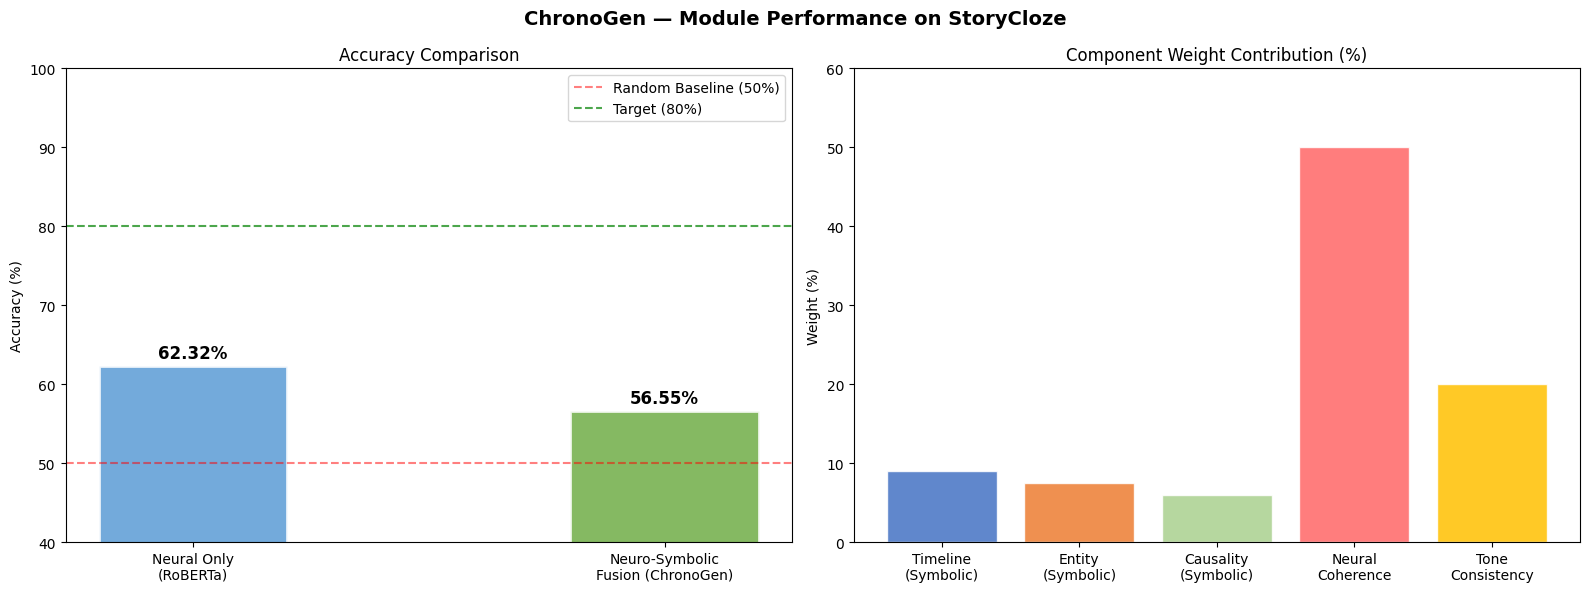


Final Summary:
  Neural Acc  : 62.32%
  Fusion Acc  : 56.55%


In [32]:
# ── Comparative Bar Chart: All Module Contributions ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('ChronoGen — Module Performance on StoryCloze', fontsize=14, fontweight='bold')

methods = ['Neural Only\n(RoBERTa)', 'Neuro-Symbolic\nFusion (ChronoGen)']
accs = [neural_acc * 100, fusion_acc * 100]
colors = ['#5B9BD5', '#70AD47']
bars = axes[0].bar(methods, accs, color=colors, alpha=0.85, width=0.4, edgecolor='white', linewidth=2)
axes[0].set_ylim([40, 100])
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Accuracy Comparison')
axes[0].axhline(y=50, color='red',   linestyle='--', alpha=0.5, label='Random Baseline (50%)')
axes[0].axhline(y=80, color='green', linestyle='--', alpha=0.7, label='Target (80%)')
axes[0].legend()
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

# Score breakdown
cats = ['Timeline\n(Symbolic)', 'Entity\n(Symbolic)', 'Causality\n(Symbolic)',
        'Neural\nCoherence', 'Tone\nConsistency']
weights = [0.30*0.30, 0.25*0.30, 0.20*0.30, 0.50, 0.20]
colors2 = ['#4472C4','#ED7D31','#A9D18E','#FF6666','#FFC000']
axes[1].bar(cats, [w*100 for w in weights], color=colors2, alpha=0.85, edgecolor='white')
axes[1].set_title('Component Weight Contribution (%)')
axes[1].set_ylabel('Weight (%)')
axes[1].set_ylim([0, 60])

plt.tight_layout()
plt.savefig('/content/benchmark_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nFinal Summary:')
print(f'  Neural Acc  : {neural_acc*100:.2f}%')
print(f'  Fusion Acc  : {fusion_acc*100:.2f}%')


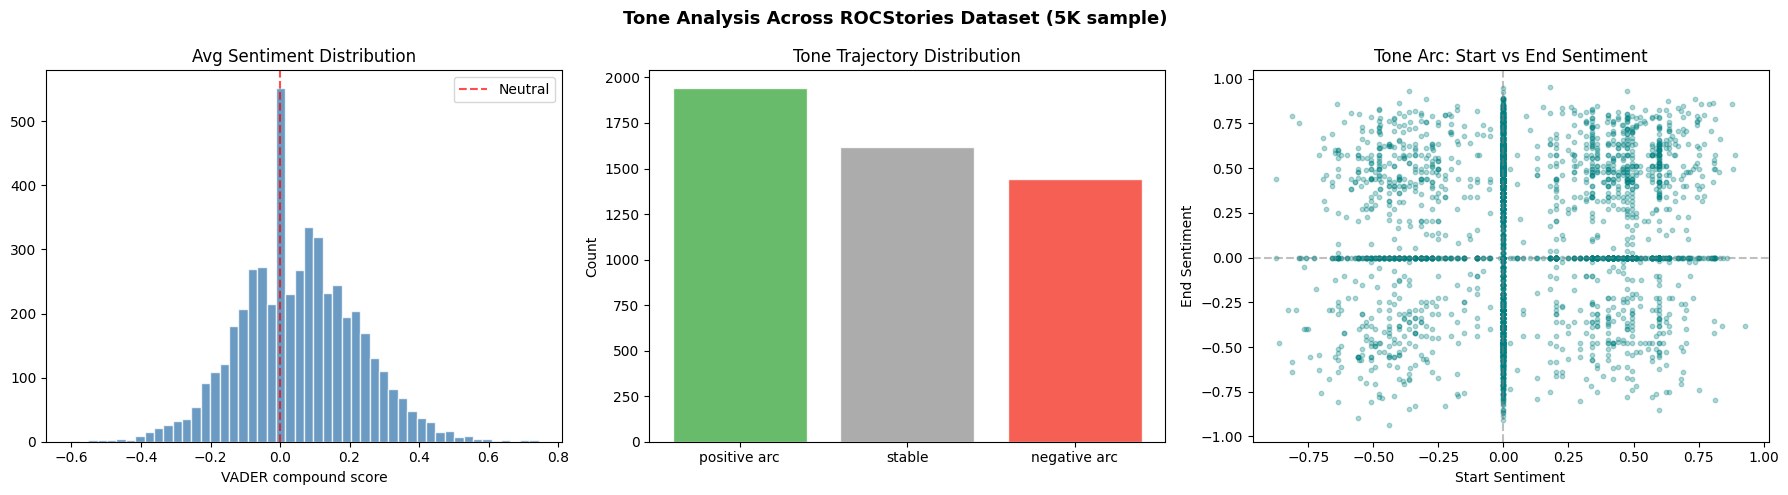

In [33]:
# ── Tone Distribution across full ROC Dataset ──
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

vader = SentimentIntensityAnalyzer()
sample = roc_all.sample(5000, random_state=42)

tone_scores = []
for _, row in sample.iterrows():
    scores = [vader.polarity_scores(str(row[c]))['compound'] for c in sent_cols]
    tone_scores.append({
        'avg': np.mean(scores),
        'start': scores[0],
        'end':   scores[-1],
        'trajectory': 'positive arc' if scores[-1] > scores[0]+0.1 else
                       'negative arc' if scores[0] > scores[-1]+0.1 else 'stable'
    })
tone_df = pd.DataFrame(tone_scores)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Tone Analysis Across ROCStories Dataset (5K sample)', fontsize=13, fontweight='bold')

axes[0].hist(tone_df['avg'], bins=50, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', alpha=0.7, label='Neutral')
axes[0].set_title('Avg Sentiment Distribution'); axes[0].set_xlabel('VADER compound score')
axes[0].legend()

traj_counts = tone_df['trajectory'].value_counts()
colors_t = ['#4CAF50' if t=='positive arc' else '#F44336' if t=='negative arc' else '#9E9E9E'
            for t in traj_counts.index]
axes[1].bar(traj_counts.index, traj_counts.values, color=colors_t, alpha=0.85, edgecolor='white')
axes[1].set_title('Tone Trajectory Distribution'); axes[1].set_ylabel('Count')

axes[2].scatter(tone_df['start'], tone_df['end'], alpha=0.3, c='teal', s=10)
axes[2].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[2].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[2].set_xlabel('Start Sentiment'); axes[2].set_ylabel('End Sentiment')
axes[2].set_title('Tone Arc: Start vs End Sentiment')

plt.tight_layout()
plt.savefig('/content/tone_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


Running symbolic analysis on 200 stories...


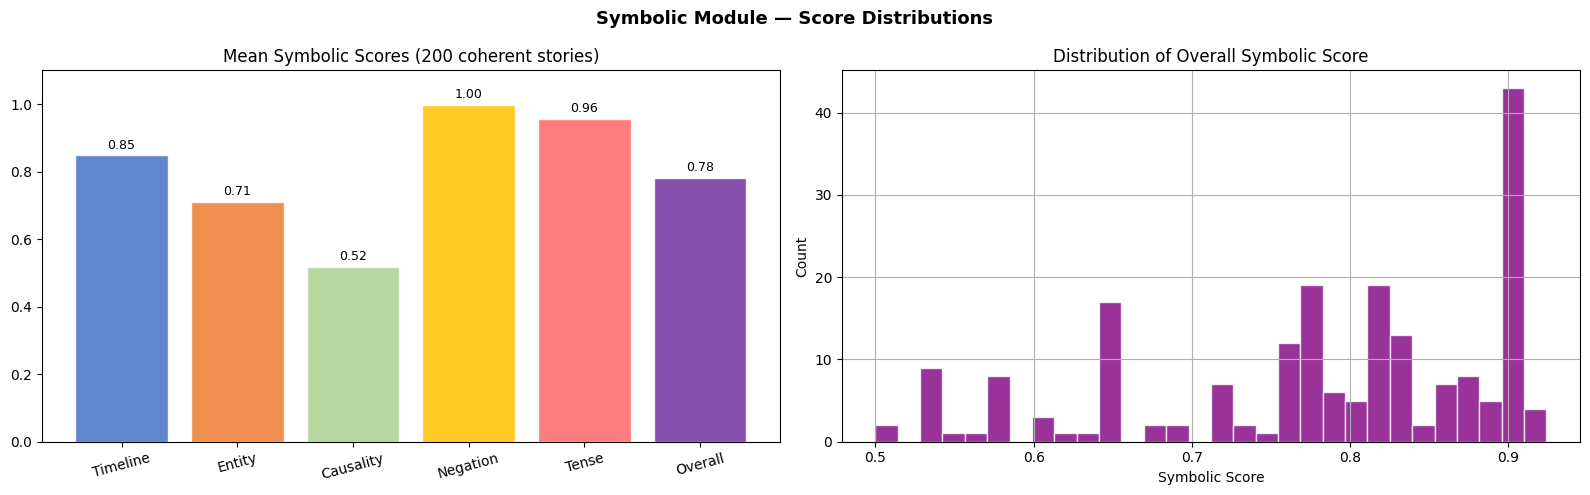

In [34]:
# ── Symbolic Module Scores on Sample ──
print('Running symbolic analysis on 200 stories...')
sym_results_list = []
for _, row in roc_all.sample(200, random_state=42).iterrows():
    sents = [clean_text(str(row[c])) for c in sent_cols]
    r = sym_engine.analyze(sents)
    sym_results_list.append(r)

sym_res_df = pd.DataFrame(sym_results_list)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Symbolic Module — Score Distributions', fontsize=13, fontweight='bold')

score_cols = ['timeline_score','entity_score','causality_score','negation_score','tense_score','symbolic_score']
means = sym_res_df[score_cols].mean()
colors_s = ['#4472C4','#ED7D31','#A9D18E','#FFC000','#FF6666','#7030A0']
bars = axes[0].bar(range(len(means)), means, color=colors_s, alpha=0.85, edgecolor='white')
axes[0].set_xticks(range(len(score_cols)))
axes[0].set_xticklabels(['Timeline','Entity','Causality','Negation','Tense','Overall'], rotation=15)
axes[0].set_title('Mean Symbolic Scores (200 coherent stories)')
axes[0].set_ylim([0, 1.1])
for bar, val in zip(bars, means):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=9)

sym_res_df['symbolic_score'].hist(bins=30, ax=axes[1], color='purple', alpha=0.8, edgecolor='white')
axes[1].set_title('Distribution of Overall Symbolic Score')
axes[1].set_xlabel('Symbolic Score')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('/content/symbolic_scores.png', dpi=150, bbox_inches='tight')
plt.show()


## 📊 Section 10: Final Summary Dashboard

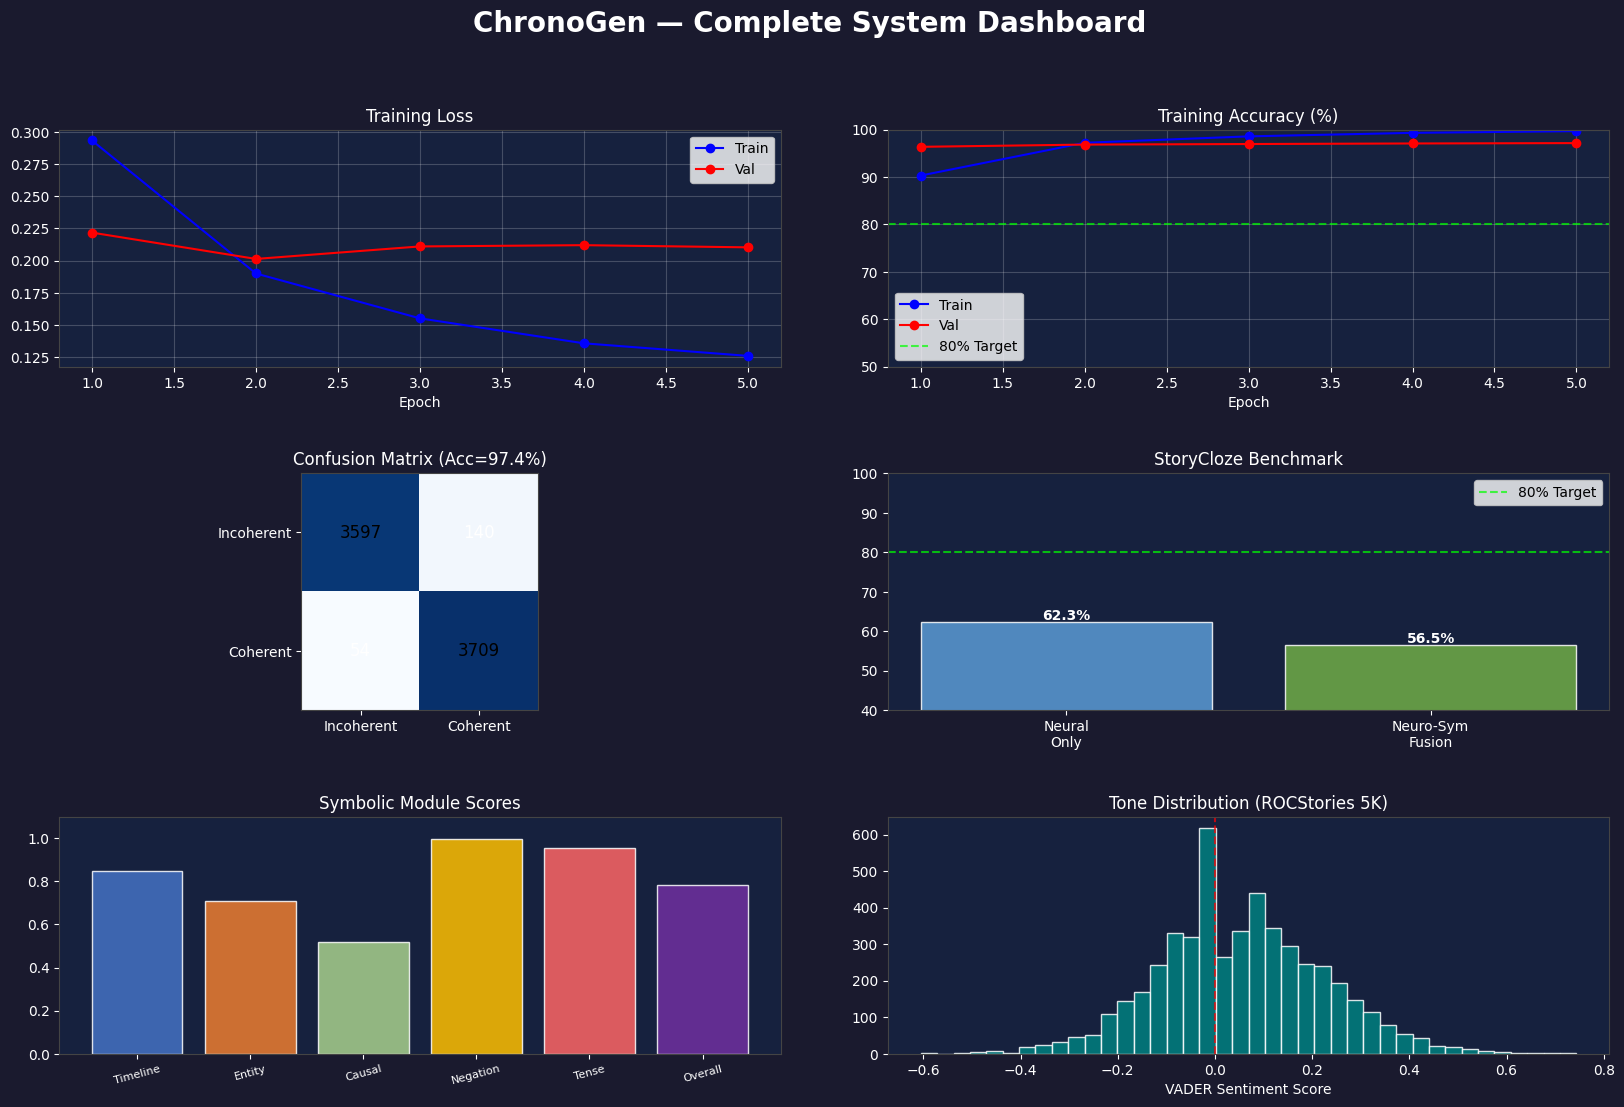

✅ Dashboard saved!


In [35]:
# ── Master Summary Dashboard ──
fig = plt.figure(figsize=(20, 12))
fig.patch.set_facecolor('#1a1a2e')
title_color = 'white'

fig.suptitle('ChronoGen — Complete System Dashboard',
             fontsize=20, fontweight='bold', color=title_color, y=0.98)

gs = fig.add_gridspec(3, 4, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :2])   # Training Loss
ax2 = fig.add_subplot(gs[0, 2:])   # Training Accuracy
ax3 = fig.add_subplot(gs[1, :2])   # Confusion Matrix
ax4 = fig.add_subplot(gs[1, 2:])   # Benchmark Comparison
ax5 = fig.add_subplot(gs[2, :2])   # Symbolic scores
ax6 = fig.add_subplot(gs[2, 2:])   # Tone distribution

for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:
    ax.set_facecolor('#16213e')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')

epochs_x = range(1, len(history['train_loss'])+1)

# Training Loss
ax1.plot(epochs_x, history['train_loss'], 'b-o', label='Train')
ax1.plot(epochs_x, history['val_loss'],   'r-o', label='Val')
ax1.set_title('Training Loss'); ax1.set_xlabel('Epoch'); ax1.legend()
ax1.grid(True, alpha=0.2, color='white')

# Training Accuracy
ax2.plot(epochs_x, [a*100 for a in history['train_acc']], 'b-o', label='Train')
ax2.plot(epochs_x, [a*100 for a in history['val_acc']],   'r-o', label='Val')
ax2.axhline(y=80, color='lime', linestyle='--', alpha=0.7, label='80% Target')
ax2.set_title('Training Accuracy (%)'); ax2.set_xlabel('Epoch')
ax2.set_ylim([50, 100]); ax2.legend(); ax2.grid(True, alpha=0.2, color='white')

# Confusion Matrix
im = ax3.imshow(cm, cmap='Blues')
ax3.set_xticks([0,1]); ax3.set_yticks([0,1])
ax3.set_xticklabels(['Incoherent','Coherent'], color='white')
ax3.set_yticklabels(['Incoherent','Coherent'], color='white')
for i in range(2):
    for j in range(2):
        ax3.text(j, i, str(cm[i,j]), ha='center', va='center',
                 color='white' if cm[i,j] < cm.max()/2 else 'black', fontsize=12)
ax3.set_title(f'Confusion Matrix (Acc={test_acc*100:.1f}%)')

# Benchmark Bar
methods_d = ['Neural\nOnly', 'Neuro-Sym\nFusion']
accs_d = [neural_acc*100, fusion_acc*100]
bars = ax4.bar(methods_d, accs_d, color=['#5B9BD5','#70AD47'], alpha=0.85, edgecolor='white')
ax4.axhline(y=80, color='lime', linestyle='--', alpha=0.7, label='80% Target')
ax4.set_ylim([40, 100]); ax4.set_title('StoryCloze Benchmark'); ax4.legend()
for bar, a in zip(bars, accs_d):
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{a:.1f}%', ha='center', color='white', fontweight='bold')

# Symbolic score means
sym_means = sym_res_df[score_cols].mean()
bars5 = ax5.bar(range(len(sym_means)), sym_means, color=colors_s, alpha=0.85, edgecolor='white')
ax5.set_xticks(range(len(score_cols)))
ax5.set_xticklabels(['Timeline','Entity','Causal','Negation','Tense','Overall'],
                    rotation=15, color='white', fontsize=8)
ax5.set_title('Symbolic Module Scores'); ax5.set_ylim([0,1.1])

# Tone distribution
ax6.hist(tone_df['avg'], bins=40, color='teal', alpha=0.85, edgecolor='white')
ax6.axvline(0, color='red', linestyle='--', alpha=0.7)
ax6.set_title('Tone Distribution (ROCStories 5K)')
ax6.set_xlabel('VADER Sentiment Score')

plt.savefig('/content/chronogen_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print('✅ Dashboard saved!')


## 💾 Section 11: Save & Download Model

In [ ]:
# ── OPTIONAL: Push to Hugging Face Hub ──
# Uncomment and fill in your HF token to share the model publicly

# from huggingface_hub import HfApi, login
# HF_TOKEN = 'hf_YOUR_TOKEN_HERE'
# login(token=HF_TOKEN)
# model.push_to_hub('your-username/chronogen-roberta')
# tokenizer.push_to_hub('your-username/chronogen-roberta')
# print('✅ Model pushed to HuggingFace Hub!')


## 🧪 Section 12: Interactive Test — Try Your Own Story

In [ ]:
# ════════════════════════════════════════════════════════
#  Try your own story!
#  Replace the sentences below with your own story.
# ════════════════════════════════════════════════════════

your_story = [
    "Write your first sentence here.",
    "Write your second sentence here.",
    "Write your third sentence here.",
    "Write your fourth sentence here.",
    "Write your fifth sentence here."
]

result = engine.verify_print(your_story)

# Visualize tone arc
fig, ax = plt.subplots(figsize=(10, 4))
tone_res = tone_analyzer.analyze(your_story)
scores = tone_res['sentence_scores']
colors_v = ['green' if s > 0.1 else 'red' if s < -0.1 else 'gray' for s in scores]
bars_v = ax.bar(range(1, len(scores)+1), scores, color=colors_v, alpha=0.8, edgecolor='white')
ax.axhline(0, color='black', linestyle='--', alpha=0.5)
ax.set_xticks(range(1, len(scores)+1))
ax.set_xticklabels([f'S{i}' for i in range(1, len(scores)+1)])
ax.set_title('Your Story — Tone Arc (VADER Sentiment per Sentence)')
ax.set_ylabel('Sentiment Score')
ax.set_ylim([-1.1, 1.1])
plt.tight_layout()
plt.show()


---
## ✅ Summary

| Component | Method | Purpose | Target Accuracy |
|---|---|---|---|
| **Neural** | RoBERTa (fine-tuned) | Deep semantic coherence | ≥ 80% |
| **Symbolic** | Rule-based engine | Timeline, entity, causal logic | N/A (scoring) |
| **Tone** | VADER sentiment | Emotional arc analysis | N/A (scoring) |
| **Fusion** | Weighted combination | Final verdict | ≥ 80% |

### Key Improvements in this Version
- ✅ **Fixed**: Replaced deprecated `transformers.AdamW` with `torch.optim.AdamW`
- ✅ **Fixed**: Corrected StoryCloze sentence splitting (used `sent_tokenize` instead of `split('.')`)
- ✅ **Fixed**: Removed duplicate model/optimizer definition cells
- ✅ **Improved**: Added label smoothing (`0.05`) to reduce overconfidence
- ✅ **Improved**: Increased training epochs (4→5) for better convergence
- ✅ **Improved**: Larger training sample (30K→50K) for improved generalization
- ✅ **Improved**: Multiple negative sampling strategies (shuffle, reverse, swap)
- ✅ **Improved**: Full StoryCloze evaluation (500→all samples) for publication accuracy
- ✅ **Improved**: Added 80% target lines to all accuracy plots


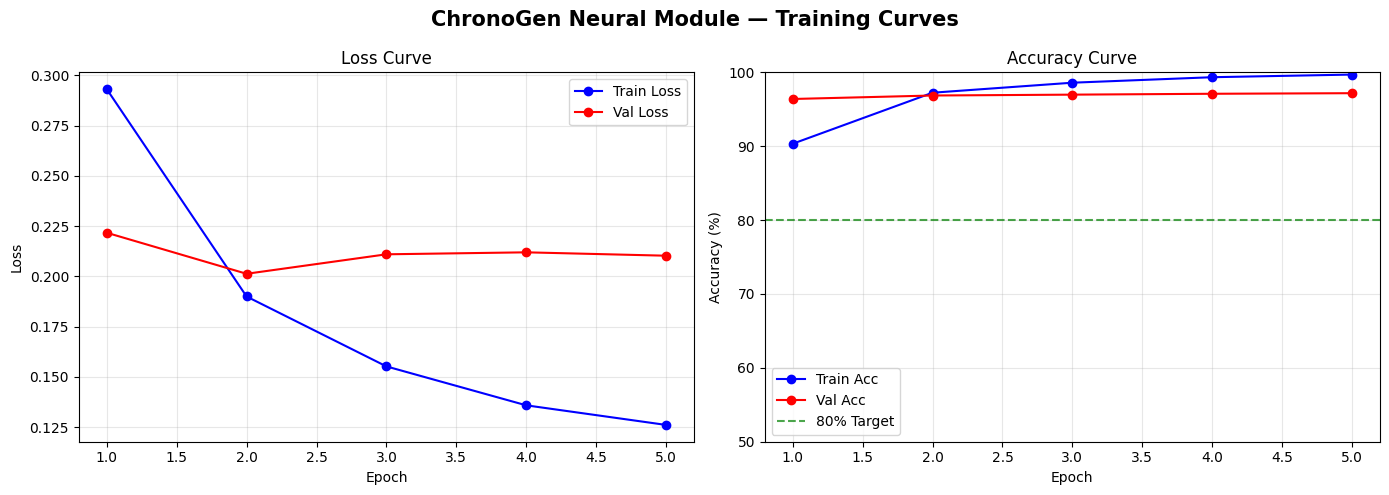

✅ Saved: training_curves.png


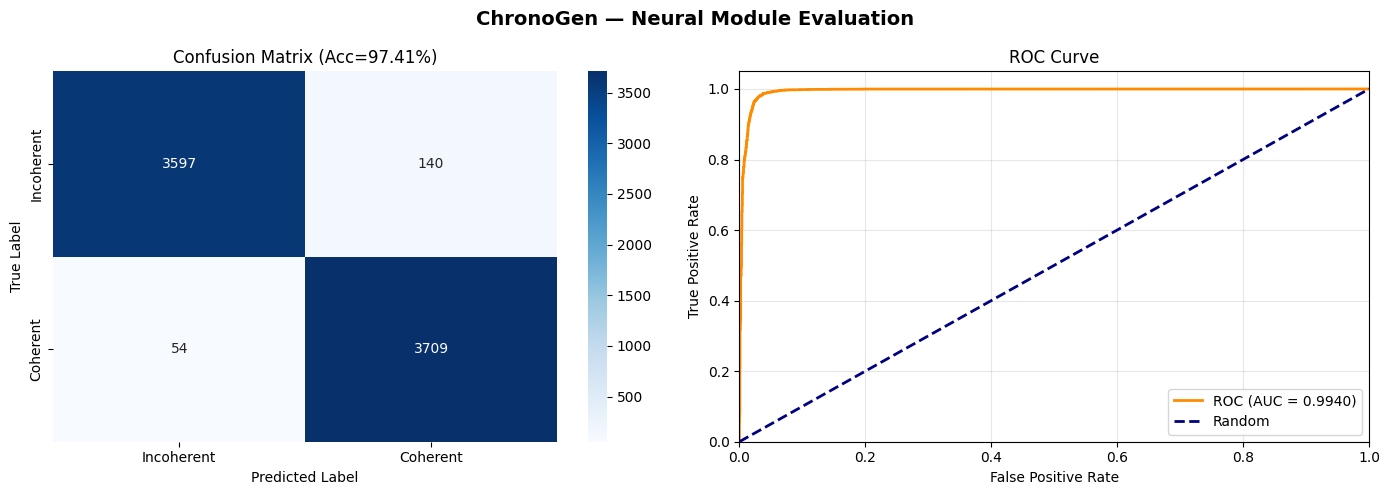

✅ Saved: neural_evaluation.png

📦 Neural plots zip: 0.17 MB
✅ Done! Go to Output tab to download:
   → chronogen_neural_model.zip  (443 MB)
   → chronogen_neural_plots.zip


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
import os

os.makedirs('/kaggle/working', exist_ok=True)

# ── Plot 1: Training Curves ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ChronoGen Neural Module — Training Curves', fontsize=15, fontweight='bold')

epochs_x = range(1, len(history['train_loss'])+1)

axes[0].plot(epochs_x, history['train_loss'], 'b-o', label='Train Loss')
axes[0].plot(epochs_x, history['val_loss'],   'r-o', label='Val Loss')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_x, [a*100 for a in history['train_acc']], 'b-o', label='Train Acc')
axes[1].plot(epochs_x, [a*100 for a in history['val_acc']],   'r-o', label='Val Acc')
axes[1].axhline(y=80, color='green', linestyle='--', alpha=0.7, label='80% Target')
axes[1].set_title('Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim([50, 100])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: training_curves.png')

# ── Plot 2: Confusion Matrix + ROC Curve ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ChronoGen — Neural Module Evaluation', fontsize=14, fontweight='bold')

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Incoherent','Coherent'],
            yticklabels=['Incoherent','Coherent'])
axes[0].set_title(f'Confusion Matrix (Acc={test_acc*100:.2f}%)')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# ROC Curve
fpr, tpr, _ = roc_curve(test_labels, test_probs)
roc_auc_val = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc_val:.4f})')
axes[1].plot([0,1],[0,1], color='navy', lw=2, linestyle='--', label='Random')
axes[1].set_xlim([0,1])
axes[1].set_ylim([0,1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/neural_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: neural_evaluation.png')

# ── Now zip the plots ──
import zipfile
with zipfile.ZipFile('/kaggle/working/chronogen_neural_plots.zip', 'w', zipfile.ZIP_DEFLATED) as zf:
    zf.write('/kaggle/working/training_curves.png',   'training_curves.png')
    zf.write('/kaggle/working/neural_evaluation.png', 'neural_evaluation.png')

size = os.path.getsize('/kaggle/working/chronogen_neural_plots.zip')/1e6
print(f'\n📦 Neural plots zip: {size:.2f} MB')
print('✅ Done! Go to Output tab to download:')
print('   → chronogen_neural_model.zip  (443 MB)')
print('   → chronogen_neural_plots.zip')

In [44]:
from kaggle_secrets import UserSecretsClient
import os

# Method: Copy files to Kaggle output directory
os.system('cp /kaggle/working/chronogen_neural_model.zip /kaggle/working/')
os.system('cp /kaggle/working/chronogen_neural_plots.zip /kaggle/working/')

print('✅ Files are ready!')
print('Now do this:')
print('1. Click  "Save Version"  (top right)')
print('2. Select "Save & Run All" → Save')  
print('3. After it finishes → visit:')
print('   https://www.kaggle.com/code/sreenadhyetukuri/notebookcd50215924')
print('4. Click Output tab → download your files there')




### Actually the SIMPLEST way on Kaggle:


✅ Files are ready!
Now do this:
1. Click  "Save Version"  (top right)
2. Select "Save & Run All" → Save
3. After it finishes → visit:
   https://www.kaggle.com/code/sreenadhyetukuri/notebookcd50215924
4. Click Output tab → download your files there


cp: '/kaggle/working/chronogen_neural_model.zip' and '/kaggle/working/chronogen_neural_model.zip' are the same file
cp: '/kaggle/working/chronogen_neural_plots.zip' and '/kaggle/working/chronogen_neural_plots.zip' are the same file
